# Random Forest Classification

In this exercise we will be tuning the RandomForest hyperparameters

Satrt by Importing useful libraries

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

Reading the data which is included in the 'data_banknote_authentication.csv' file

In [7]:
df = pd.read_csv('/content/data_banknote_authentication.csv')
df.head()

,Variance_Wavelet,Skewness_Wavelet,Curtosis_Wavelet,Image_Entropy,Class
0,3.62160,8.6661,-2.8073,-0.44699,0
1,4.54590,8.1674,-2.4586,-1.46210,0
2,3.86600,-2.6383,1.9242,0.10645,0
3,3.45660,9.5228,-4.0112,-3.59440,0
4,0.32924,-4.4552,4.5718,-0.98880,0


Diving the data into features and labels (X and y)

In [8]:
X = df.drop('Class',axis=1)
y = df['Class']

Splitting the data into train and test parts

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=101)

Use the RandomForest model with a GridSearch to optimize 'n_estimators', 'max_features' and 'criterion' parameters

In [14]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

In [15]:
rf = RandomForestClassifier(random_state=101)
n_estimators = list(range(1,20))
param_grid = {
    'n_estimators': n_estimators,  # Number of trees
    'max_features': ['sqrt', 'log2'],  # Number of features to consider at each split
    'criterion': ['gini', 'entropy']  # Function to measure the quality of a split
}
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5, n_jobs=-1,scoring='accuracy')
grid_search.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=101),
             n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_features': ['sqrt', 'log2'],
                         'n_estimators': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12,
                                          13, 14, 15, 16, 17, 18, 19]},
             scoring='accuracy')

Evaluate the model by displaying a confusion matrix and a classification report

In [16]:
pred=grid_search.predict(X_test)

In [17]:
from sklearn.metrics import confusion_matrix,classification_report
confusion_matrix(y_test,pred)
print(classification_report(y_test,pred))

              precision    recall  f1-score   support

           0       1.00      0.99      0.99       238
           1       0.98      1.00      0.99       174

    accuracy                           0.99       412
   macro avg       0.99      0.99      0.99       412
weighted avg       0.99      0.99      0.99       412



In [18]:
rf2 = RandomForestClassifier(n_estimators=9,max_features='log2',criterion='entropy',random_state=101)
rf2.fit(X_train,y_train)
pred2=rf2.predict(X_test)
confusion_matrix(y_test,pred2)
print(classification_report(y_test,pred2))

              precision    recall  f1-score   support

           0       1.00      0.98      0.99       238
           1       0.97      1.00      0.99       174

    accuracy                           0.99       412
   macro avg       0.99      0.99      0.99       412
weighted avg       0.99      0.99      0.99       412



In [19]:
test_error = []

for n in range(1,40):
    # Use n random trees
    model = RandomForestClassifier(n_estimators=n,max_features=None)
    model.fit(X_train,y_train)
    test_preds = model.predict(X_test)
    test_error.append(1-accuracy_score(test_preds,y_test))

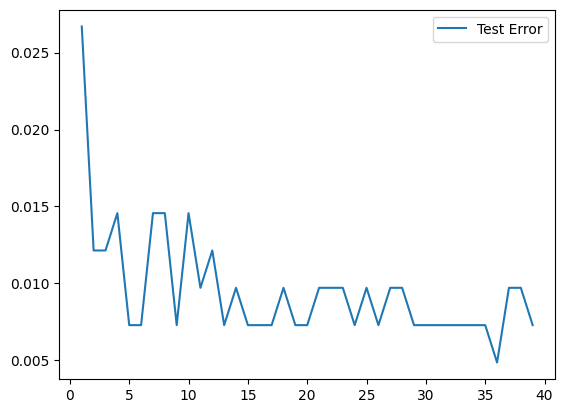

In [20]:
plt.plot(range(1,40),test_error,label='Test Error')
plt.legend()